In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

stocks = ["AAPL", "BLK", "GS", "JPM", "MSFT"]

# Hypothetical one-period shocks, not historical forecasts
scenarios = pd.DataFrame({
    "Broad Market Crash": [-0.30, -0.35, -0.40, -0.35, -0.30],
    "Banking Crisis":     [-0.10, -0.35, -0.45, -0.40, -0.10],
    "Technology Selloff": [-0.40, -0.15, -0.15, -0.15, -0.45],
    "Severe Combined":    [-0.45, -0.50, -0.55, -0.50, -0.45]
}, index=stocks)

display((scenarios * 100).round(1))

,Broad Market Crash,Banking Crisis,Technology Selloff,Severe Combined
AAPL,-30.0,-10.0,-40.0,-45.0
BLK,-35.0,-35.0,-15.0,-50.0
GS,-40.0,-45.0,-15.0,-55.0
JPM,-35.0,-40.0,-15.0,-50.0
MSFT,-30.0,-10.0,-45.0,-45.0


In [2]:

# Day 14 — Step 2: Portfolio stress-test results

# Portfolio weights from your Day 13 results
weights = pd.DataFrame({
    "Equal Weight": [0.20, 0.20, 0.20, 0.20, 0.20],
    "Minimum Variance": [0.3327, 0.1311, 0.0, 0.1787, 0.3575],
    "Risk Parity": [0.2475, 0.1742, 0.1350, 0.1783, 0.2650]
}, index=stocks)

# Validate that each portfolio is fully invested
assert np.allclose(weights.sum(), 1.0)

initial_investment = 10000

# Each scenario is a one-period shock
stress_returns = scenarios.T @ weights
stress_losses = stress_returns * initial_investment
remaining_values = initial_investment + stress_losses

print("Portfolio returns under stress (%):")
display((stress_returns * 100).round(2))

print("Dollar profit/loss ($):")
display(stress_losses.round(2))

print("Remaining portfolio value ($):")
display(remaining_values.round(2))

Portfolio returns under stress (%):


,Equal Weight,Minimum Variance,Risk Parity
Broad Market Crash,-34.0,-31.55,-33.11
Banking Crisis,-28.0,-18.64,-24.43
Technology Selloff,-26.0,-34.04,-29.14
Severe Combined,-49.0,-46.55,-48.11


Dollar profit/loss ($):


,Equal Weight,Minimum Variance,Risk Parity
Broad Market Crash,-3400.0,-3154.90,-3311.25
Banking Crisis,-2800.0,-1863.85,-2442.90
Technology Selloff,-2600.0,-3404.25,-2913.75
Severe Combined,-4900.0,-4654.90,-4811.25


Remaining portfolio value ($):


,Equal Weight,Minimum Variance,Risk Parity
Broad Market Crash,6600.0,6845.10,6688.75
Banking Crisis,7200.0,8136.15,7557.10
Technology Selloff,7400.0,6595.75,7086.25
Severe Combined,5100.0,5345.10,5188.75


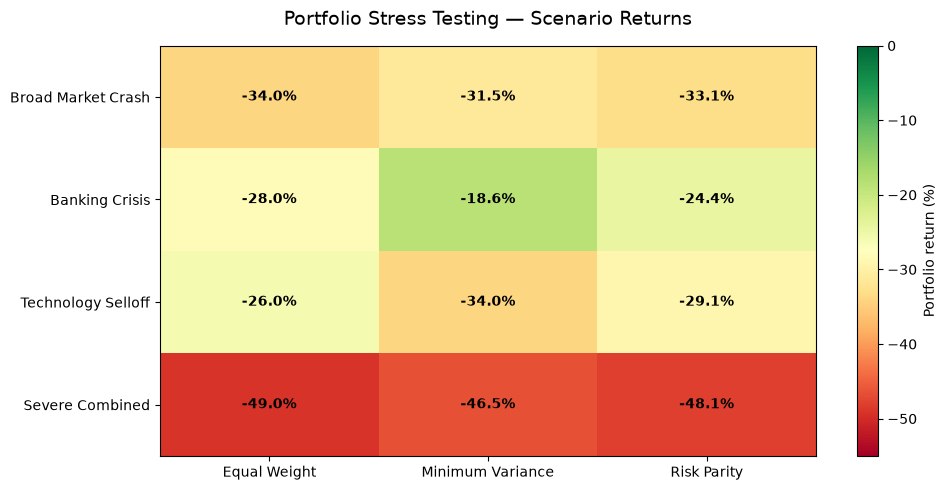

In [3]:

import matplotlib.pyplot as plt
import numpy as np

# Portfolio percentage returns for each stress scenario
heatmap_data = stress_returns * 100

fig, ax = plt.subplots(figsize=(10, 5))

im = ax.imshow(heatmap_data.values, cmap="RdYlGn",
               aspect="auto", vmin=-55, vmax=0)

ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)

ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

# Display each scenario's percentage return
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]
        ax.text(j, i, f"{value:.1f}%",
                ha="center", va="center",
                color="black", fontweight="bold")

ax.set_title("Portfolio Stress Testing — Scenario Returns",
             fontsize=14, pad=15)

plt.colorbar(im, ax=ax, label="Portfolio return (%)")
plt.tight_layout()
plt.show()

In [4]:

# Worst loss across the four hypothetical scenarios
worst_case = stress_returns.min(axis=0) * 100
worst_scenario = stress_returns.idxmin(axis=0)

worst_case_summary = pd.DataFrame({
    "Worst Scenario": worst_scenario,
    "Worst Loss (%)": worst_case,
    "Loss on $10,000 ($)": -worst_case * 100,
    "Remaining Value ($)": 10000 * (1 + worst_case / 100)
})

display(worst_case_summary.round(2))

,Worst Scenario,Worst Loss (%),"Loss on $10,000 ($)",Remaining Value ($)
Equal Weight,Severe Combined,-49.00,4900.00,5100.00
Minimum Variance,Severe Combined,-46.55,4654.90,5345.10
Risk Parity,Severe Combined,-48.11,4811.25,5188.75



## Day 14 — Research Conclusion

The stress test evaluates three portfolio construction methods
across four hypothetical market shocks.

Minimum variance experienced a modeled loss of 18.6% in the
banking-crisis scenario, compared with 28.0% for equal weight
and 24.4% for risk parity.

During the technology selloff, minimum variance lost 34.0%,
compared with 26.0% for equal weight and 29.1% for risk parity.

The severe combined scenario produced losses of 49.0%,
46.55%, and 48.11%, respectively.

These results demonstrate that portfolio construction
influences exposure to different market shocks. Lower
historical volatility does not guarantee smaller losses
under every stress scenario.

### Limitations
The scenarios are hypothetical, the portfolio contains
only five equities, and the analysis assumes instantaneous
price shocks without modeling liquidity constraints,
market impact, or changing correlations.